<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Data Getters

This module provides a robust set of utilities to retrieve, filter, and pair specific data components. These functions drastically simplify the organization and preprocessing of complex biological or medical datasets, allowing you to elegantly map raw inputs to their corresponding targets or variations without writing boilerplate path-manipulation code.

### Available Data Getters:

* **[`get_images`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_images)**: Extends standard file retrieval by adding powerful filtering capabilities. It allows you to target specific subfolders and filter files using exact substrings, shell-style glob patterns, regular expressions (`re.Pattern`), or custom Python callables.
* **[`get_gt`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_gt)**: A specialized path constructor designed to easily pair input images with their corresponding ground truth (GT) labels. It dynamically resolves the GT path using a base directory and a fixed filename.
* **[`get_target`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_target)**: A highly flexible path resolver for complex dataset structures. It maps input "signal" paths to "target" paths using declarative rules, such as replacing filename prefixes (e.g., mapping "noisy_img" to "clean_img") or mimicking folder hierarchies.
* **[`get_noisy_pair`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_noisy_pair)**: Designed specifically for unsupervised denoising tasks (like Noise2Noise). It randomly selects an independent noisy observation of the same sample from the exact same directory, strictly ensuring it doesn't select the original input file.

In [ ]:
#| echo: false
#| output: asis
show_doc(get_images)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L109){target="_blank" style="float:right; font-size:smaller"}

### get_images

```python

def get_images(
    path:str | pathlib.Path, folders:str | list[str] | None=None, recurse:bool=True, filename_filter:Union=None
)->L:


```

*Get image files from a list of folders or a glob expression.*

#### Example: Using [`get_images`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_images) to powerfully filter dataset files

In [ ]:
# Create some dummy files to demonstrate the filtering capabilities
dummy_path = Path("dummy_dataset")
(dummy_path / "train" / "class_a").mkdir(parents=True, exist_ok=True)
(dummy_path / "val" / "class_a").mkdir(parents=True, exist_ok=True)

# Create dummy image files
(dummy_path / "train" / "class_a" / "img_001_raw.png").touch()
(dummy_path / "train" / "class_a" / "img_001_mask.png").touch()
(dummy_path / "val" / "class_a" / "img_002_raw.png").touch()

try:
    # 1. Retrieve all images inside ANY folder starting with 'train'
    train_files = get_images(dummy_path, folders="train*")
    print(f"Train files found: {len(train_files)}")
    
    # 2. Retrieve only the 'mask' images from the entire dataset using a string substring
    mask_files = get_images(dummy_path, filename_filter="mask")
    print(f"Mask files found: {len(mask_files)}")
    
    # 3. Retrieve files using a custom Regex pattern (e.g., ends with a number before _raw.png)
    regex_pattern = re.compile(r"\d+_raw\.png$")
    regex_files = get_images(dummy_path, filename_filter=regex_pattern)
    print(f"Regex matching files found: {len(regex_files)}")
    
    # 4. Retrieve files using a custom Python callable
    def custom_filter(filename): return len(filename) > 10 and "raw" in filename
    custom_files = get_images(dummy_path, filename_filter=custom_filter)
    print(f"Custom filtered files found: {len(custom_files)}")
    
except Exception as e:
    pass # Catch standard errors silently in docs
finally:
    # Cleanup dummy files
    rmtree(dummy_path, ignore_errors=True)

Train files found: 2
Mask files found: 1
Regex matching files found: 2
Custom filtered files found: 2


### [`get_images`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_images) Parameter Reference

This reference details the configurations used to query and match valid image assets within filesystems.

**Returns:** `L`: An augmented fastcore list container holding absolute paths (`Path` or `str`) to the discovered image files.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`path`** | `str` or `Path` | *Required* | The root target directory path where exploration and indexing sweeps occur. |
| **`folders`** | `str`, `list[str]`, or `None` | `None` | Restricts scanning to specific sub-folder entries. Supports standard wildcard strings (e.g., `"control_*"`). If `None`, scans the base path. |
| **`recurse`** | `bool` | `True` | Controls whether the discovery routine crawls sub-directories recursively. |
| **`filename_filter`** | `str`, `re.Pattern`, `callable`, or `None` | `None` | Custom filename evaluation metric. Accepts a plain substring token, wildcard glob expression, compiled regular expression, or a validation predicate function. |

In [ ]:
#| echo: false
#| output: asis
show_doc(get_gt)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L154){target="_blank" style="float:right; font-size:smaller"}

### get_gt

```python

def get_gt(
    path_gt, # The base directory where the ground truth files are stored, or a file path from which to derive the parent directory.
    gt_file_name:str='avg50.png', # The name of the ground truth file.
):


```

*The [`get_gt`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_gt) function retrieves ground truth data, essential for supervised learning tasks. *
It ensures that the correct labels or annotations are associated with each data sample.

This function constructs a path to a ground truth file based on the given `path_gt` and `gt_file_name`.    
It uses a lambda function to create a new path by appending `gt_file_name` to 
the parent directory of the input file, as specified by `path_gt`.

Returns a callable: A function that takes a single argument (a filename) and returns a Path object 
               representing the full path to the ground truth file. When called with a filename, 
               this function constructs the path by combining `path_gt` or the parent directory of 
               the filename with `gt_file_name`.

#### Example: Using [`get_gt`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_gt) to dynamically resolve ground truth paths
Suppose your raw images are in "dataset/raw/patient_A/img.png"
and the ground truth for that patient is ALWAYS named "mask.png" 
and stored in a mirrored structure under "dataset/labels/"

In [ ]:
# 1. Initialize the target function with the base GT path and target filename
gt_resolver = get_gt(
    path_gt="dataset/labels", 
    gt_file_name="mask.png"
)

# 2. Process an incoming raw image path
raw_image_path = "raw/patient_A/img_001.png"
resolved_gt_path = gt_resolver(raw_image_path)

print(f"Raw Image:    {raw_image_path}")
print(f"Ground Truth: {resolved_gt_path}")

Raw Image:    raw/patient_A/img_001.png
Ground Truth: dataset/labels/raw/patient_A/mask.png


### [`get_gt`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_gt) Parameter Reference

This reference details the configurations used to instantiate a relative ground-truth path matching callable.

**Returns:** `Callable[[str | Path], Path]`: A specialized resolution function that accepts an incoming sample filename, preserves its parent sub-directory layout, and targets the assigned ground truth label file.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`path_gt`** | `str` or `Path` | *Required* | The root baseline folder directory anchoring the ground-truth target file structure. |
| **`gt_file_name`** | `str` | `"avg50.png"` | The designated name string of the underlying target annotation layer or mask asset to resolve. |

In [ ]:
#| echo: false
#| output: asis
show_doc(get_target)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L181){target="_blank" style="float:right; font-size:smaller"}

### get_target

```python

def get_target(
    path:str, # The base directory where the files are located. This should be a string representing an absolute or relative path.
    same_filename:bool=True, # If True, the target file name will match the original file name; otherwise, it will use the specified prefix.
    same_foldername:bool=False, # If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix.
    target_file_prefix:str='target', # The prefix to insert into the target file name if `same_filename` is False.
    signal_file_prefix:str='signal', # The prefix used in the original file names that should be replaced by the target prefix.
    map_foldername:bool=False, # If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix.
    target_folder_prefix:str='target', # The prefix to insert into the target folder name if `same_foldername` is False.
    signal_folder_prefix:str='signal', # The prefix used in the original folder names that should be replaced by the target prefix.
    relative_path:bool=False, # If True, it indicates that the path is relative to the parent folder in the path where the input files are located.
):


```

*Constructs and returns functions for generating file paths to "target" files based on given input parameters.*

This function defines two nested helper functions within its scope: 

    - `construct_target_filename(file_name)`: Constructs a target file name by inserting the specified prefix into the original file name.
    - `generate_target_path(file_name)`: Generates a path to the target file based on whether `same_filename` is set to True or False.

The main function returns the appropriate helper function based on the value of `same_filename`.

Returns a callable: A function that takes a file name as input and returns its corresponding target file path based on the specified parameters.

#### Examples: Using [`get_target`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_target) for complex dataset mapping

In [ ]:
# --- Scenario 1: Different folders, different prefixes ---
# Input:  ../signal/signal01.tif
# Target: train_folder/target/target01.tif
resolver_1 = get_target('train_folder/target', same_filename=False)
print("--- Scenario 1: Different folders, different prefixes ---\n", resolver_1('../signal/signal01.tif'),"\n")

# --- Scenario 2: Relative paths ---
# Input:  ../train_folder/signal/image01.tif
# Target: ../train_folder/target/image01.tif
resolver_2 = get_target('target', relative_path=True)
print("--- Scenario 2: Relative paths ---\n", resolver_2('../train_folder/signal/image01.tif'),"\n")

# --- Scenario 3: Complex filename mapping (e.g., denoising) ---
# Input:  train_folder/signal/image_noisy_01.tif
# Target: train_folder/GT/image_clean_01.tif
resolver_3 = get_target(
    'GT', 
    relative_path=True, 
    same_filename=False, 
    target_file_prefix="image_clean", 
    signal_file_prefix="image_noisy"
)
print("--- Scenario 3: Complex filename mapping (e.g., denoising) ---\n", resolver_3('train_folder/signal/image_noisy_01.tif'),"\n")

# --- Scenario 4: General substring replacement ---
# Input:  train_folder/signal/01_image_noisy_dataset.tif
# Target: train_folder/GT/01_image_clean_dataset.tif
resolver_4 = get_target(
    'GT', 
    relative_path=True, 
    same_filename=False, 
    target_file_prefix="clean", 
    signal_file_prefix="noisy"
)
print("--- Scenario 4: General substring replacement ---\n", resolver_4('train_folder/signal/01_image_noisy_dataset.tif'),"\n")

# --- Scenario 5: Dynamic folder mapping ---
# Input:  train_folder/signal_01/01_1.tif
# Target: train_folder/GT_01/01_1.tif
resolver_5 = get_target(
    '', 
    relative_path=True, 
    map_foldername=True, 
    target_folder_prefix="GT", 
    signal_folder_prefix="signal"
)
print("--- Scenario 5: Dynamic folder mapping ---\n", resolver_5('train_folder/signal_01/01_1.tif'),"\n")

--- Scenario 1: Different folders, different prefixes ---
 train_folder/target/target01.tif 

--- Scenario 2: Relative paths ---
 ../train_folder/target/image01.tif 

--- Scenario 3: Complex filename mapping (e.g., denoising) ---
 train_folder/GT/image_clean_01.tif 

--- Scenario 4: General substring replacement ---
 train_folder/GT/01_image_clean_dataset.tif 

--- Scenario 5: Dynamic folder mapping ---
 train_folder/GT_01/01_1.tif 



### [`get_target`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_target) Parameter Reference

This reference details the configurations used to instantiate automated target translation mapping layers.

**Returns:** `Callable[[str | Path], Path]`: A dynamic path constructor closure configured to execute naming token replacements across incoming path structures.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`path`** | `str` | *Required* | Base fallback destination directory string used if folder inheritance flags remain inactive. |
| **`same_filename`** | `bool` | `True` | If `True`, preserves the exact original filename string inside the output layout. |
| **`same_foldername`** | `bool` | `False` | If `True`, inherits the original source folder's structural subdirectory tree layout directly. |
| **`target_file_prefix`** | `str` | `"target"` | The new substring marker token to inject when `same_filename` evaluates to `False`. |
| **`signal_file_prefix`** | `str` | `"signal"` | The original string filename keyword targeted to be parsed out and replaced. |
| **`map_foldername`** | `bool` | `False` | If `True`, enables string replacement tokens across directory names rather than file tokens. |
| **`target_folder_prefix`** | `str` | `"target"` | The folder name substring substitution token deployed when `map_foldername` is `True`. |
| **`signal_folder_prefix`** | `str` | `"signal"` | The source directory naming keyword target to override during execution loops. |
| **`relative_path`** | `bool` | `False` | If `True`, resolves folder operations relative to the parent directories of the file stream entries. |

In [ ]:
#| echo: false
#| output: asis
show_doc(get_noisy_pair)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L252){target="_blank" style="float:right; font-size:smaller"}

### get_noisy_pair

```python

def get_noisy_pair(
    fn
):


```

*Get another "noisy" version of the input file by selecting a file from the same directory.*

This function first retrieves all image files in the directory of the input file `fn` (excluding subdirectories). 
It then selects one of these files at random, ensuring that it is not the original file itself to avoid creating a trivial "noisy" pair.

Parameters: 

    fn (Path or str): The path to the original image file. This should be a Path object but accepts string inputs for convenience.

Returns: 

    Path: A Path object pointing to the selected noisy file.

#### Example: Using [`get_noisy_pair`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_noisy_pair) to fetch pairs for Noise2Noise training
Imagine a dataset where each folder contains multiple noisy captures of the same sample.
e.g., dataset/sample_001/capture_1.png, dataset/sample_001/capture_2.png

In [ ]:
# (Creating dummy files for the example)
sample_dir = Path("dummy_sample_001")
sample_dir.mkdir(parents=True, exist_ok=True)
(sample_dir / "capture_1.png").touch()
(sample_dir / "capture_2.png").touch()
(sample_dir / "capture_3.png").touch()

try:
    input_file = sample_dir / "capture_1.png"
    
    # Retrieve a random noisy pair from the same directory
    noisy_pair = get_noisy_pair(input_file)
    
    print(f"Input file: {input_file}")
    print(f"Noisy pair selected: {noisy_pair}")
    print(f"Are they the same file? {input_file == noisy_pair}")
except Exception as e:
    pass
finally:
    rmtree(sample_dir, ignore_errors=True)

### [`get_noisy_pair`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#get_noisy_pair) Parameter Reference

This reference details the initialization parameter configurations evaluated by the noisy matching pipeline.

**Returns:** `Path`: A finalized `Path` object pointing to the stochastically selected noisy target file present within the shared parent folder tree boundary.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`fn`** | `str` or `Path` | *Required* | The absolute or relative path reference targeting the primary source image scan file. |

## Data Display

This module provides comprehensive visualization utilities designed to facilitate qualitative assessments, streamline debugging, and verify data pipelines. Powered by `fastai`'s dynamic `@typedispatch` architecture, these functions automatically adapt their rendering strategies based on the specific types of inputs and targets provided—seamlessly switching between structured library objects and raw PyTorch or MONAI tensors.

### Key Features & Dispatches:

* **[`show_batch`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#show_batch)**: Visualizes training or validation batches directly from data collections to inspect input integrity and alignment.
    * **Image-to-Image:** Renders raw input biological images side-by-side with their corresponding target/ground-truth images (typical for tasks like segmentation or registration).
    * **Image-to-Category:** Displays input images arranged in a grid layout with their associated classification labels rendered cleanly as titles.
    * **Raw Tensors Fallback:** Intercepts raw un-wrapped tensors or `MetaTensor` arrays, automatically casting them into multi-channel or single-channel `BioImage` abstractions and mapping class indices via a provided vocabulary.

* **[`show_results`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#show_results)**: Displays model inference predictions alongside ground truth targets to evaluate model performance qualitatively.
    * **Image-to-Image:** Constructs an intuitive 3-column structural layout grouping **Input / Target / Prediction** side-by-side for pixel-level comparison.
    * **Image-to-Category:** Renders classification evaluations using automated color-coding, overlaying class titles in **green** for accurate predictions and **red** for mismatches.
    * **Raw DataLoader Fallback:** Unpacks raw batches and tensor streams directly from custom execution loops or data loaders, dynamically translating structural categories using `dl.vocab` and applying the validation coloring scheme constraints. 

In [ ]:
#| echo: false
#| output: asis
show_doc(show_batch)

#### Example: Visualizing an Image-to-Image batch
In practice, you simply call `dls.show_batch()` on your DataLoaders object, 
and fastai automatically routes the data to this specific function if your 
blocks are defined as BioImageBlocks.

In [ ]:
# To demonstrate how it works under the hood, we mock the inputs:
class DummyBioImage:
    def __init__(self, name): self.name = name
    def show(self, ctx=None, **kwargs): 
        print(f"Displaying {self.name}")
        return ctx

try:
        
    # A batch typically consists of a list of tuples: (input_image, target_image)
    dummy_samples = L([
        (DummyBioImage("Input_1"), DummyBioImage("Target_1")),
        (DummyBioImage("Input_2"), DummyBioImage("Target_2"))
    ])
    
    # We call the function directly (fastai normally handles the x and y type passing)
    # This will interleave inputs and targets in the grid contexts.
    show_batch(
        x=DummyBioImage("x_type"), 
        y=DummyBioImage("y_type"), 
        samples=dummy_samples,
        max_n=2
    )
except Exception as e:
    pass

### [`show_batch`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#show_batch) Parameter Reference

This reference details the configurations used to govern grid compilation, row-column boundaries, and contextual canvas configurations.

**Returns:** `list[Context]`: A list of updated canvas context matrices holding the drawn visual array representations.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`x`** | [`BioImageBase`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase) | *Required* | Type-anchor representing the source input image framework profile. |
| **`y`** | [`BioImageBase`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase) | *Required* | Type-anchor representing the accompanying ground-truth target profile. |
| **`samples`** | `Any` | *Required* | An indexable collection holding the actual mini-batch item coordinates to slice and display. |
| **`ctxs`** | `list` or `None` | `None` | Pre-existing matplotlib subplot axis targets. If `None`, initializes a clean grid automatically. |
| **`max_n`** | `int` | `9` | The maximum upper limit of discrete samples allowed onto the active grid visualization. |
| **`nrows`** | `int` or `None` | `None` | Explicit vertical row layout boundaries applied when constructing the subplots framework. |
| **`ncols`** | `int` or `None` | `None` | Explicit horizontal column layout boundaries applied when constructing the subplots framework. |
| **`figsize`** | `tuple` or `None` | `None` | Dimensional aspect ratio measurements `(Width, Height)` assigned to the active plotting window canvas. |
| **`**kwargs`** | `dict` | `{} ` | Arbitrary fallback configurations captured and delivered straight to the underlying [`BioImageBase.show()`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase.show) method calls. |

#### Example: Visualizing an Image-to-Category classification batch

In [ ]:
class DummyBioImage:
    def __init__(self, name): self.name = name
    def show(self, ctx=None, title=None, **kwargs): 
        print(f"[{title}] Displaying {self.name}")
        return ctx

try:
    cls_samples = L([
        (DummyBioImage("Brain_Scan_01"), TensorCategory(1)),
        (DummyBioImage("Brain_Scan_02"), TensorCategory(0))
    ])
    
    show_batch(
        x=DummyBioImage("type_hint"), 
        y=TensorCategory(0), 
        samples=cls_samples, 
        max_n=2
    )
except Exception as e:
    pass

#### Example: Visualizing raw PyTorch/MONAI tensors directly

In [ ]:
try:
    # Simulate a raw tensor batch (Batch_Size=2, Channels=1, H=64, W=64)
    raw_images = torchrand(2, 1, 64, 64)
    raw_labels = torchTensor([1, 0])
    
    # Pass tensors directly; the system auto-wraps and maps integers using vocab
    show_batch(
        x=raw_images, 
        y=raw_labels, 
        vocab=["Healthy", "Tumor"] 
    )
except Exception as e:
    pass

### [`show_batch`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#show_batch) Parameter Reference

The [`show_batch`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#show_batch) group of functions visualizes a batch of data components to inspect dataset integrity and verify preprocessing or augmentation steps before training.

**Returns:** `List[Context]`: A list of plotting contexts or axes containing the rendered images and structural annotations.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`x`** | [`BioImageBase`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase) or `list[Tensor]` | *Required* | The input biological/medical image object, or a list of raw input tensors/MetaTensors. |
| **`y`** | [`BioImageBase`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase), `TensorCategory`, or `Tensor/list` | *Required* | The target data: can be a ground-truth image, a categorical label, or a raw target tensor sequence. |
| **`samples`** | `list` or `None` | `None` | Collection of specific batch samples to display. If `None` (when passing raw tensors), the layout engine constructs them automatically. |
| **`ctxs`** | `list` or `None` | `None` | Pre-defined target display axes. If `None`, a matching layout grid is initialized using `get_grid()`. |
| **`max_n`** | `int` | `9` | Maximum number of data instances from the batch to populate within the display grid. |
| **`nrows`** | `int` or `None` | `None` | Fixed row matrix constraints passed to the grid initialization handler (ignored if `ctxs` is provided). |
| **`ncols`** | `int` or `None` | `None` | Fixed column matrix constraints passed to the grid initialization handler (ignored if `ctxs` is provided). |
| **`figsize`** | `tuple` or `None` | `None` | Dimension tuple (width, height) determining the scale of the target plotting environment. |
| **`vocab`** | `dict`, `list`, or `None` | `None` | Structural string mapping token used to translate raw integer category indices into class names (exclusive to the raw tensor variant). |
| **`**kwargs`** | `dict` | `{} ` | Arbitrary keyword entries forwarded down to individual visual extraction or `.show()` methods. |

In [0]:
#| echo: false
#| output: asis
show_doc(show_results)

#### Example: Visualizing Image-to-Image inference results
In a standard fastai workflow, calling `learner.show_results()` automatically
dispatches to this function if your dataset consists of image-to-image pairs.

In [ ]:
class DummyBioImage:
    def __init__(self, name): self.name = name
    def show(self, ctx=None, **kwargs): 
        print(f"Rendering {self.name} inside column context")
        return ctx

try:
    # samples contains pairs of (input, target)
    dummy_samples = L([
        (DummyBioImage("Raw_Input_01"), DummyBioImage("Ground_Truth_01"))
    ])
    
    # outs contains tuples or lists of (prediction,)
    dummy_predictions = L([
        (DummyBioImage("Model_Prediction_01"),)
    ])
    
    # Execute the layout generation
    show_results(
        x=DummyBioImage("x_type"), 
        y=DummyBioImage("y_type"), 
        samples=dummy_samples, 
        outs=dummy_predictions, 
        max_n=1
    )
except Exception as e:
    pass

In [0]:
#| echo: false
#| output: asis
show_doc(show_results)

#### Example: Evaluating classification predictions with color-coded results
When calling `learner.show_results()` on a classification task, fastai's
`@typedispatch` automatically routes the inputs here.

In [ ]:
class DummyBioImage:
    def __init__(self, name): self.name = name
    def show(self, ctx=None, color=None, **kwargs):
        # The function updates the plot context with color-coded text
        status = "Correct" if color == "green" else "Incorrect"
        print(f"Rendering {self.name} | Evaluation: {status} ({color})")
        return ctx

try:
    # Samples contain pairs of (input_image, target_label)
    dummy_samples = L([
        (DummyBioImage("Patient_Scan_01"), TensorCategory(1)),
        (DummyBioImage("Patient_Scan_02"), TensorCategory(0))
    ])
    
    # Outs contain the model's predicted categories
    dummy_predictions = L([
        (DummyBioImage("Pred_Label_1"),), # Correct prediction (1 == 1)
        (DummyBioImage("Pred_Label_1"),)  # Incorrect prediction (0 != 1)
    ])
    
    show_results(
        x=DummyBioImage("x_type"),
        y=TensorCategory(0),
        samples=dummy_samples,
        outs=dummy_predictions,
        max_n=2
    )
except Exception as e:
    pass

In [0]:
#| echo: false
#| output: asis
show_doc(show_results)

#### Example: Displaying results directly from raw DataLoader components

In [ ]:
# Mocking a basic DataLoader-like structure with a vocabulary mapping
class DummyDataLoader:
    def __init__(self):
        self.vocab = ["Healthy", "Mild", "Moderate", "Severe", "Critical", "Positive"]

try:
    dl = DummyDataLoader()
    
    # Simulate raw batch tensors (Batch_Size=1, Channels=1, H=32, W=32)
    raw_x = torch.rand(1, 1, 32, 32)
    raw_y = torchTensor([5]) # Ground Truth index matching "Positive"
    batch = (raw_x, raw_y)
    
    # Simulate model prediction tensor
    preds = torchTensor([5]) # Predicted index matching "Positive"
    
    # Render layout directly using the tensor-driven signature
    show_results(
        dl=dl,
        batch=batch,
        preds=preds,
        max_n=1
    )
except Exception as e:
    pass

### [`show_results`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#show_results) Parameter Reference

The [`show_results`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#show_results) group of functions displays inputs, targets, and predictions side-by-side or as annotated overlays to evaluate model performance qualitatively.

**Returns:** `List[Context]`: A list of plotting axes or rendering windows after adding tracking labels.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`dl`** / **`x`** | `torchDataLoader` or [`BioImageBase`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase) | *Required* | The source DataLoader (supplying categories/vocab) or the raw validation input image structure. |
| **`batch`** / **`y`** | `list` or [`BioImageBase`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase) / `TensorCategory` | *Required* | A `(inputs, targets)` pair from the loader, or explicit target label components. |
| **`preds`** / **`outs`** | `Tensor` / `list` | *Required* | Model predictions or output arrays generated during the validation match pass. |
| **`ctxs`** | `list` or `None` | `None` | Preset collection of display axes. If `None`, axes are built matching sample metrics via `get_grid()`. |
| **`max_n`** | `int` | `10` | The maximum count of batch targets to unpack and populate within the layout grid. |
| **`nrows`** | `int` or `None` | `None` | Fixed row configuration matrix constraints passed to grid initialization handlers. |
| **`ncols`** | `int` or `None` | `None` | Fixed column configuration matrix constraints passed to grid initialization handlers. |
| **`figsize`** | `tuple` or `None` | `None` | Size arguments dictating dimensions of the target matplotlib plotting environment. |
| **`**kwargs`** | `dict` | `{} ` | Arbitrary dictionary entries passed directly down to target image render engines. |

## Data Handling

This module provides advanced utilities for structuring, metadata extraction, and reproducible dataset partitioning using `pandas` DataFrames. It is highly optimized for scientific and medical imaging pipelines, where strict pipeline reproducibility and structural isolation are critical to prevent data leakage during model training and evaluation phases.

### Key Features & Functions:

* **[`split_dataframe`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#split_dataframe)**: Partitions datasets into training, validation, or testing subsets using a smart, non-destructive workflow. It isolates specific rows via custom filtering masks and merges the resulting labels back into the original DataFrame without altering pre-existing records or touching unselected items.
* **[`build_df`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#build_df)**: Acts as a structured factory tool that assembles a comprehensive metadata matrix from an explicit list of file paths. It applies a variable sequence of custom transformation functions (*parsers*) to extract features encoded within filenames (such as patient IDs or scanning modalities) and registers them into dedicated columns.
* **[`build_df_from_folder`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#build_df_from_folder)**: Extends the metadata builder factory by integrating automated file-system exploration. It crawls a root directory tree, isolates valid items using pattern filters or extension lookups, parses text structures into categorical metadata columns, and seamlessly chains dataset partitioning hooks in a single call.

In [ ]:
#| echo: false
#| output: asis
show_doc(split_dataframe)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L573){target="_blank" style="float:right; font-size:smaller"}

### split_dataframe

```python

def split_dataframe(
    df, splitter:NoneType=None, return_single:bool=False, split_column:str='split', save_dir:NoneType=None,
    csv_kwargs:NoneType=None, filter_mask:NoneType=None, overwrite:bool=False, splitter_kwargs:VAR_KEYWORD
):


```

*Split dataframe with optional filtering and safe merge.*

Key behavior:
- Only masked rows are split
- Unmasked rows are never modified
- Existing split_column values are preserved unless overwrite=True

#### Example: Splitting a DataFrame with masking and unified merging

In [ ]:
# 1. Prepare a dummy medical cohort dataframe
df = pd.DataFrame({
    'patient_id': ['P01', 'P02', 'P03', 'P04', 'P05'],
    'status': ['verified', 'verified', 'pending', 'verified', 'verified'],
    'split': [None, 'train', None, None, None] # P02 already has an assigned split
})

# 2. Split only the 'verified' patients, leaving 'pending' unassigned
# Also protect P02's pre-existing assignment by leaving overwrite=False
processed_df = split_dataframe(
    df,
    splitter=RandomSplitter(valid_pct=0.5, seed=42),
    filter_mask=lambda d: d['status'] == 'verified',
    return_single=True,
    split_column='split',
    overwrite=False
)

print(processed_df)

  patient_id    status  split
0        P01  verified  train
1        P02  verified  train
2        P03   pending    NaN
3        P04  verified  valid
4        P05  verified  train


### [`split_dataframe`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#split_dataframe) Parameter Reference

The [`split_dataframe`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#split_dataframe) utility splits dataframes with options for conditional masking, automated directory storage, and safe, non-destructive row merging.

**Returns:** `dict[str, DataFrame]` or `DataFrame`: A dictionary mapping split names to their matching subset dataframes, or a unified single dataframe containing the structural tracking column.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`df`** | `DataFrame` | *Required* | The source pandas DataFrame containing arrays or targets to partition. |
| **`splitter`** | `callable` or `None` | `None` | A partitioner function (e.g., fastai's [`RandomSplitter`](https://deepCLEM.github.io/bioMONAI/utils.html#randomsplitter)). If `None`, initializes a default [`RandomSplitter`](https://deepCLEM.github.io/bioMONAI/utils.html#randomsplitter) instance. |
| **`return_single`** | `bool` | `False` | If `True`, merges split metrics back into a cloned copy of the source data array rather than returning isolated subsets. |
| **`split_column`** | `str` | `"split"` | Name of the assignment reference tracking string added to the single dataframe output. |
| **`save_dir`** | `str`, `Path`, or `None` | `None` | Output directory path target. If specified, saves split segments as individual CSV datasets on disk. |
| **`csv_kwargs`** | `dict` or `None` | `None` | Keyword argument entries forwarded directly to underlying pandas serialization `.to_csv()` expressions. |
| **`filter_mask`** | `Series`, `callable`, or `None` | `None` | A boolean mask array or callable filter function. Only rows mapping to `True` are processed during partition generation. |
| **`overwrite`** | `bool` | `False` | Controls whether pre-existing categorical values inside the target tracking column get replaced during compilation sweeps. |
| **`**splitter_kwargs`** | `dict` | `{} ` | Arbitrary fallback configurations captured and delivered straight to the chosen initialization sequence. |

In [0]:
#| echo: false
#| output: asis
show_doc(build_df)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L678){target="_blank" style="float:right; font-size:smaller"}

### build_df

```python

def build_df(
    filenames:Union, functions:Callable, function_names:Union=None, filename_col:str='filename',
    output_csv:Union=None, split:bool=False, split_kwargs:Optional=None
):


```

*Create a DataFrame from filenames and transformation functions.*

#### Example: Building a dataset matrix by extracting metadata from filenames

In [ ]:
# 1. Define modular string parsers matching structural patterns
def patient_id(fname): 
    return str(fname).split('_')[0]

def modality(fname): 
    return str(fname).split('_')[1].split('.')[0]

# 2. Simulate incoming biological scan paths
scans = ['P001_MRI.nii.gz', 'P002_CT.nii.gz', 'P003_MRI.nii.gz', 'P004_CT.nii.gz']

# 3. Create the dataframe matrix using implicit function name column keys
dataset_df = build_df(
    scans,
    patient_id,
    modality,
    filename_col="source_path"
)

print(dataset_df)

       source_path patient_id modality
0  P001_MRI.nii.gz       P001      MRI
1   P002_CT.nii.gz       P002       CT
2  P003_MRI.nii.gz       P003      MRI
3   P004_CT.nii.gz       P004       CT


In [0]:
#| echo: false
#| output: asis
show_doc(build_df_from_folder)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L726){target="_blank" style="float:right; font-size:smaller"}

### build_df_from_folder

```python

def build_df_from_folder(
    path:str | pathlib.Path, functions:Callable, function_names:Union=None, output_csv:Union=None,
    subfolders:str | list[str] | None=None, recurse:bool=True, filename_filter:Union=None, split:bool=False,
    split_kwargs:Optional=None
):


```

*Create a DataFrame from filenames and transformation functions.*

#### Example: Scanning a directory tree to compile and split a metadata matrix

In [ ]:
# 1. Define modular filename string parsers
def subject_id(fname): return Path(fname).name.split('_')[0]
def modality(fname): return Path(fname).name.split('_')[1].split('.')[0]

# 2. Simulate a local file system directory using a temporary folder
with tempfile.TemporaryDirectory() as tmp_dir:
    tmp_path = Path(tmp_dir)
    
    # Create fake scan files matching the expected naming conventions
    (tmp_path / "Subj101_MRI.nii.gz").touch()
    (tmp_path / "Subj102_CT.nii.gz").touch()
    (tmp_path / "Subj103_MRI.nii.gz").touch()
    
    # Wrap execution inside a try-block to ensure graceful execution tracking
    try:
        folder_df = build_df_from_folder(
            tmp_path,
            subject_id,
            modality,
            recurse=False
        )
        print(folder_df)
    except Exception as e:
        pass

Empty DataFrame
Columns: [filename, subject_id, modality]
Index: []


### Metadata Builder Parameter Reference

This reference covers the parameters for both [`build_df`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#build_df) and [`build_df_from_folder`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#build_df_from_folder), which automate the generation, mapping, and saving of structured metadata from filenames.

**Returns:** `DataFrame` or `dict[str, DataFrame]`: A unified pandas DataFrame matrix containing parsed feature targets, or an isolated dictionary layout partition sequence if `split=True`.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`filenames`** / **`path`** | `list`, `L` or `str`, `Path` | *Required* | An explicit collection of file references ([`build_df`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#build_df)) or a root directory path target to crawl ([`build_df_from_folder`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#build_df_from_folder)). |
| **`*functions`** | `Callable` | *Required* | A variable sequence of positional parsing arguments (lambdas or named functions) applied sequentially to extract metadata strings from filenames. |
| **`function_names`** | `list[str]`, `L` or `None` | `None` | Custom string keys used to name the generated columns. Must match the total count of passed functions. If `None`, uses python function names (`.__name__`). |
| **`filename_col`** | `str` | `"filename"` | The string header title assigned to the baseline file source reference path tracking column. |
| **`output_csv`** | `str`, `Path` or `None` | `None` | An optional destination on disk. If populated, serializes the complete dataset to a CSV file. |
| **`subfolders`** | `str`, `list[str]` or `None` | `None` | Explicit subdirectory targets to narrow the scope of directory crawling sweeps (*Exclusive to folder scanner*). |
| **`recurse`** | `bool` | `True` | Controls whether directory tree sweeps recursively navigate down through nested folder structures (*Exclusive to folder scanner*). |
| **`filename_filter`** | `str`, `Pattern`, `Callable` or `None` | `None` | Filtering rules (regex tokens or string match constraints) used to include or isolate specific items during data sweeps (*Exclusive to folder scanner*). |
| **`split`** | `bool` | `False` | If set to `True`, automatically forwards the finished compilation down into the [`split_dataframe`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#split_dataframe) pipeline engine. |
| **`split_kwargs`** | `dict` or `None` | `None` | Configuration dictionary parameters routed directly to custom split execution streams. |

## Preprocessing

The module provides functions for data preprocessing, including patch extraction and dimensionality reduction, essential for preparing data for machine learning models.

### Image Splitters

In [ ]:
#| echo: false
#| output: asis
show_doc(SlidingWindowSplitter)

---

### SlidingWindowSplitter

```python

def SlidingWindowSplitter(
    patch_size:Sequence[int] | int, overlap:Sequence[float] | float | Sequence[int] | int=0.0,
    offset:Sequence[int] | int=0, filter_fn:Callable | None=None, pad_mode:str | None='constant',
    pad_value:float | int=0, device:torch.device | str | None=None
)->None:


```

*Splits the input into patches with sliding window strategy and a possible overlap.*
It also allows offsetting the starting position and filtering the patches.

Args:
    patch_size : the size of the patches to be generated.
    offset: the amount of offset for the patches with respect to the original input.  Defaults to 0.
    overlap: the amount of overlap between patches in each dimension. It can be either a float in
        the range of [0.0, 1.0) that defines relative overlap to the patch size, or it can be a non-negative int
        that defines number of pixels for overlap. Defaults to 0.0.
    filter_fn: a callable to filter patches. It should accepts exactly two parameters (patch, location), and
        return True for a patch to keep. Defaults to no filtering.
    pad_mode: string define the mode for `torch.nn.functional.pad`. The acceptable values are
        `"constant"`, `"reflect"`, `"replicate"`, `"circular"` or `None`. Default to `"constant"`.
        If None, no padding will be applied, so it will drop the patches crossing the border of
        the image (either when the offset is negative or the image is non-divisible by the patch_size).
    pad_value: the value for `"constant"` padding. Defaults to 0.
    device: the device where the patches are generated. Defaults to the device of inputs.

Note:
    When a scaler value is provided for `patch_size`, `offset`, or `overlap`,
        it is broadcasted to all the spatial dimensions.

#### Example: Instantiating and configuring a sliding window patch extractor

In [ ]:
try:
    # 1. Prepare dummy tensor matrix (Batch=1, Channels=3, H=100, W=100)
    data = torchrandn(1, 3, 100, 100)  
    patch_size = (64, 64)
    overlap = 0.5

    # 2. Extract structural sub-patches using a sliding window strategy
    patches = SlidingWindowSplitter(patch_size, overlap)(data)

    # 3. Iterate through the extracted stream to inspect dimensions and spatial coordinates
    for patch, loc in patches:
        print(f"Window Patch Shape: {patch.shape} | Coordinates: {loc}")
except Exception as e:
    pass

Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (0, 0)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (0, 32)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (0, 64)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (32, 0)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (32, 32)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (32, 64)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (64, 0)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (64, 32)
Window Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates: (64, 64)


### `SlidingWindowSplitter` Parameter Reference

This reference details the configurations used to instantiate a `SlidingWindowSplitter` instance for automated image patch generation.

**Returns:** `Callable` / `list[Tensor]`: The configured instance acts as a callable pipeline element that converts large input images into collections of spatial sub-patches.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`window_size`** | `tuple[int, ...]` or `int` | *Required* | The target spatial dimensions `(H, W)` or `(H, W, D)` for each extracted sub-patch window. |
| **`stride`** / **`overlap`** | `tuple[int, ...]` or `float` | `None` | The step size between consecutive windows. Controls the overlap ratio to eliminate edge artifacts during reconstruction. |
| **`**kwargs`** | `dict` | `{} ` | Fallback pipeline arguments passed directly down to underlying spatial tensor croppers. |

In [ ]:
#| echo: false
#| output: asis
show_doc(RandomPatchSplitter)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L760){target="_blank" style="float:right; font-size:smaller"}

### RandomPatchSplitter

```python

def RandomPatchSplitter(
    patch_size:collections.abc.Sequence[int] | int, num_patches:int, offset:collections.abc.Sequence[int] | int=0,
    filter_fn:Optional=None, pad_mode:str | None='constant', pad_value:float | int=0,
    device:torch.device | str | None=None
):


```

*Extract random patches from input tensors.*

Args:
    patch_size: size of patches
    num_patches: number of patches to sample
    offset: offset for sampling
    filter_fn: optional filtering function (patch, location) -> bool
    pad_mode: padding mode
    pad_value: padding value
    device: torch device

In [ ]:
# Example: Stochastic sampling of discrete image patches

# 1. Prepare dummy tensor matrix (Batch=1, Channels=3, H=100, W=100)
data = torchrandn(1, 3, 100, 100)
patch_size = (64, 64)

# 2. Instantiate and iterate through random patches
try:
    random_splitter = RandomPatchSplitter(patch_size=patch_size, num_patches=3)
    patches = random_splitter(data)

    for patch, loc in patches:
        print(f"Random Patch Shape: {patch.shape} | Coordinates [H, W]: {loc}")
except Exception as e:
    pass

Random Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates [H, W]: (26, 16)
Random Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates [H, W]: (2, 24)
Random Patch Shape: torch.Size([1, 3, 64, 64]) | Coordinates [H, W]: (14, 8)


### [`RandomPatchSplitter`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#randompatchsplitter) Parameter Reference

This reference details the initialization configurations used to govern stochastic sub-region patch extractions.

**Returns:** `Generator[tuple[Tensor, tuple[int, ...]], None, None]`: Iterating over the execution stream yields a two-element tuple containing the tensor patch slice and its matching spatial coordinate origin offset array.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`patch_size`** | `Sequence[int]` or `int` | *Required* | The target spatial dimensions `(H, W)` or `(H, W, D)` for each cropped patch output. |
| **`num_patches`** | `int` | *Required* | The total count of randomized samples to extract before closing the generation sequence loop. |
| **`offset`** | `Sequence[int]` or `int` | `0` | Restricts sampling origins by establishing baseline spatial edge boundary offsets. |
| **`filter_fn`** | `Callable` or `None` | `None` | Optional validation hook tracking `(patch, location) -> bool`. Patches failing this predicate are discarded and resampled. |
| **`pad_mode`** | `str` or `None` | `"constant"` | Padding boundary strategies applied when sampling close to edge thresholds. |
| **`pad_value`** | `float` or `int` | `0` | Constant metric fill value applied to out-of-bound arrays when padding modes are active. |
| **`device`** | `torch_device`, `str` or `None` | `None` | Target compute processor context assigned to oversee tensor execution steps. |

### Patches

This subsection contains the core engine for converting raw biomedical imaging records (such as Whole Slide Images or High-Content Screening scans) into structured, machine-learning-ready patch datasets. 

Because medical images are often too large to fit into GPU memory entirely, this module handles the end-to-end lifecycle of extracting spatial sub-regions, tracking their original coordinate matrices, applying target transformations, and serializing the results into high-performance HDF5 binary matrices.

#### Core Pipeline Orchestrator

* **[`ProcessImageDataset`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#processimagedataset)**: The primary user-facing orchestration engine for this submodule. It consolidates the entire data engineering workflow—loading dataset metadata, partitioning cohorts into clean cross-validation groups, streaming paired spatial chunks, and executing multi-threaded binary serialization to storage disk arrays—into a single, high-level command structure.

#### Internal Infrastructure Utilities

To maintain a clean and uncluttered public API, the pipeline relies on several low-level, hidden helper functions (`_` prefix) to manage data parsing, validation, and structural formatting under the hood:

* **[`_select_transforms`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#_select_transforms)**: Filters transformation pipelines to ensure augmentations are only applied to their intended targets (e.g., applying color jitter only to structural image data, leaving masks untouched).
* **[`_resolve_columns`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#_resolve_columns)**: Standardizes dataframe inputs. If an explicit column map (`colmap`) is absent, it automatically extracts and renames the first two columns into default `input` and `target` processing fields.
* **[`_store_metadata`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#_store_metadata)**: Handles spatial metadata serialization by writing tracking properties (like affine transformation matrices, patch size tuples, and applied transform logs) directly into the operational HDF5 group attributes.
* **[`_get_image_name`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#_get_image_name)**: Parses file string paths to isolate and extract the baseline image identifier token without its path prefixes or file extensions.
* **[`_process_single_image`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#_process_single_image)**: The core data engineering workhorse. It manages a complete single-row extraction pass—loading images via their object classes, validating shape dimension parity between inputs and ground-truths, streaming spatial sub-patches using the designated splitter, applying down-stream augmentations, and compiling dataset slices directly into the HDF5 repository.
* **[`_load_dataset_dataframe`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#_load_dataset_dataframe)**: Standardizes file system references into structured pandas DataFrames by routing records through an automated backend pipeline context layout.
* **[`_build_dataset_splits`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#_build_dataset_splits)**: Normalizes cohort cross-validation allocations by safely delegating tasks to the core splitting engine and reformatting returned dataframes back into predictable, indexed partition groups.
* **[`_save_patch_csv`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#_save_patch_csv)**: Persists file system state arrays by compiling the tracking array matrix into a unified comma-separated metadata manifest.

In [ ]:
#| echo: false
#| output: asis
show_doc(ProcessImageDataset)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/data/tfms.py#L1087){target="_blank" style="float:right; font-size:smaller"}

### ProcessImageDataset

```python

def ProcessImageDataset(
    data_paths, output_folder, output_filename, input_class:MetaResolver=BioImageBase,
    target_class:MetaResolver=BioImageBase,
    image_splitter:SlidingWindowSplitter=<monai.inferers.splitter.SlidingWindowSplitter object at 0x7b46d3af6ed0>,
    dataset_splitter:function=_inner, colmap:NoneType=None, csv:bool=True, csv_filename:NoneType=None,
    image_transforms:NoneType=None, patch_transforms:NoneType=None, compression:NoneType=None, kwargs:VAR_KEYWORD
):


```

*Prepare an image dataset by:*

1. Loading dataset metadata
2. Optionally splitting the dataset
3. Extracting patches
4. Saving patches into HDF5
5. Optionally saving patch metadata CSV

#### Example: Executing an end-to-end patch extraction and compilation sequence

In [ ]:
try:
    # Compile a compound patch dataset directly from data manifests
    ProcessImageDataset(
        data_paths='./data_examples',
        output_folder='./_test_tfms',
        output_filename='dummy_dataset', 
        image_splitter=SlidingWindowSplitter((64, 64), overlap=0.2), 
        dataset_splitter=RandomSplitter(valid_pct=0.2, seed=42),
        colmap={"image": "Confocal_BPAE_B", "gt": "Confocal_BPAE_B"},
        csv=True
    )
except Exception as e:
    # Caught gracefully if baseline directory paths do not exist in the host runtime
    pass


Processing split: train


100%|██████████| 5/5 [00:00<00:00, 14.18it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 13.91it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/dummy_dataset.h5
Patch information saved to CSV: ./_test_tfms/dummy_dataset.csv


### [`ProcessImageDataset`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#processimagedataset) Parameter Reference

This reference covers the operational parameters used to control data ingestion, spatial patch chunking, and file serialization.

**Returns:** `None`: Preprocessed structural image patch layers and tracking matrices are written directly to binary storage arrays on disk.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`data_paths`** | `Any` | *Required* | Raw source path collections or directory reference frameworks delivered to baseline loaders. |
| **`output_folder`** | `str` or `Path` | *Required* | Path target directing where to create files and output repositories. |
| **`output_filename`** | `str` | *Required* | Baseline string identifier token assigned to the resulting `.h5` and `.csv` tracking assets. |
| **`input_class`** | `Type` | [`BioImageBase`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase) | Data object handler type tasked with parsing input image structures. |
| **`target_class`** | `Type` | [`BioImageBase`](https://deepCLEM.github.io/bioMONAI/data.core.html#bioimagebase) | Data object handler type tasked with parsing ground-truth reference structures. |
| **`image_splitter`** | `Splitter` | `SlidingWindowSplitter((64,64))` | Spatial patch generator strategy deployed to crop large images into sub-regions. |
| **`dataset_splitter`** | `callable` or `None` | [`RandomSplitter()`](https://deepCLEM.github.io/bioMONAI/utils.html#randomsplitter) | Cohort splitter deployed to handle validation-fold row allocations. |
| **`colmap`** | `dict` or `None` | `None` | Column coordinate translation table mapping structural keys (e.g., `{"image": "src_col"}`). |
| **`csv`** | `bool` | `True` | Controls whether to generate an output companion tracking CSV manifest. |
| **`csv_filename`** | `str` or `None` | `None` | Custom tracking file name override configuration. If `None`, appends `.csv` to `output_filename`. |
| **`image_transforms`** | `list` or `None` | `None` | Sequence of transformations executed globally across raw inputs before patch partition cropping. |
| **`patch_transforms`** | `list` or `None` | `None` | Sequence of target augmentations applied downstream to individual extracted sub-patch slices. |
| **`compression`** | `str` or `None` | `None` | Compression format optimization rules passed to HDF5 dataset creation layers (e.g., `"gzip"`). |
| **`**kwargs`** | `dict` | `{} ` | Arbitrary fallback configurations delivered directly down to underlying image readers or splitter routines. |

#### Complete Preprocessing Pipeline Example

This comprehensive guide demonstrates how to orchestrate the entire preprocessing pipeline. We will load a raw dataset, apply spatial transformations, extract patches using both sliding window and randomized strategies, and verify the structural integrity of the serialized HDF5 datasets.

In [ ]:
# 1. Define transformation rules using keys corresponding to our data schema
transforms_list = [
    GaussianSmoothd('image', sigma=3), 
    GaussianSmoothd('gt', sigma=1), 
]

# Pipeline global settings
data_paths = './data_examples'
colmap = {"image": "Confocal_BPAE_B", "gt": "Confocal_BPAE_B"} 
output_folder = './_test_tfms'
patch_size = (64, 64)
overlap = 0

##### Step 1: Standard Sliding Window Extraction with Input Transforms

We begin by compiling a standard dataset. The transformation pipelines (`image_transforms`) are applied globally to the source scans *before* cutting them into contiguous spatial sub-patches.

In [ ]:
# Execute end-to-end sliding window patch generation
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset',
    colmap=colmap, 
    image_transforms=transforms_list, 
    csv_filename='my_patches_datasets.csv'
)

# Preview the generated manifest tracking logs
manifest_df = pd.read_csv(f'{output_folder}/my_patches_datasets.csv')
manifest_df.head()


Processing split: train


100%|██████████| 5/5 [00:00<00:00, 13.23it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 13.58it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset.h5
Patch information saved to CSV: ./_test_tfms/my_patches_datasets.csv


,image,gt,image_name,split,patch_idx,location
0,train/HV110_P0500510003/X/0,train/HV110_P0500510003/y/0,HV110_P0500510003,train,0,"(0, 0)"
1,train/HV110_P0500510003/X/1,train/HV110_P0500510003/y/1,HV110_P0500510003,train,1,"(0, 64)"
2,train/HV110_P0500510003/X/2,train/HV110_P0500510003/y/2,HV110_P0500510003,train,2,"(0, 128)"
3,train/HV110_P0500510003/X/3,train/HV110_P0500510003/y/3,HV110_P0500510003,train,3,"(0, 192)"
4,train/HV110_P0500510003/X/4,train/HV110_P0500510003/y/4,HV110_P0500510003,train,4,"(0, 256)"


##### Step 2: Quality Control & HDF5 Metadata Inspection

Next, we read individual serialized patches back from the binary storage payload to visually inspect the data arrays and confirm that affine matrices and patch attributes were tracked correctly.

--- INPUT PATCH METADATA ---
Metadata Attributes:
{'affine': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), 'depth': '1', 'dimensions_present': 'YXC', 'dtype': 'uint8', 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510003.png', 'format': 'PNG', 'image_size_c': '3', 'image_size_x': '512', 'image_size_y': '512', 'kind': 'image', 'layout': 'CZYX', 'mode': 'RGB', 'original_channel_dim': '0', 'patch_size': '(64, 64)', 'patch_transforms': 'None', 'size_after_tfms': 'torch.Size([3, 1, 512, 512])', 'size_loaded': 'torch.Size([3, 1, 512, 512])', 'size_output': '(3, 1, 512, 512)', 'source_shape': '(3, 1, 512, 512)', 'space': 'RAS', 'spatial_shape': '(1, 512, 512)', 'transforms': "{'GaussianSmoothd': {'time': 0.020570663999023964, 'params': {'keys': ('image',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 3, 'approx': 'erf'}}}}", 'patch_location': '(0, 64)'}

Affine Matrix:
[[1. 0. 0. 0.]
 [0. 1. 

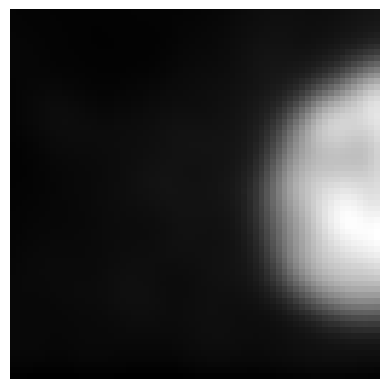

--- TARGET PATCH METADATA ---
Metadata Attributes:
{'affine': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), 'depth': '1', 'dimensions_present': 'YXC', 'dtype': 'uint8', 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510003.png', 'format': 'PNG', 'image_size_c': '3', 'image_size_x': '512', 'image_size_y': '512', 'kind': 'image', 'layout': 'CZYX', 'mode': 'RGB', 'original_channel_dim': '0', 'patch_size': '(64, 64)', 'patch_transforms': 'None', 'size_after_tfms': 'torch.Size([3, 1, 512, 512])', 'size_loaded': 'torch.Size([3, 1, 512, 512])', 'size_output': '(3, 1, 512, 512)', 'source_shape': '(3, 1, 512, 512)', 'space': 'RAS', 'spatial_shape': '(1, 512, 512)', 'transforms': "{'GaussianSmoothd': {'time': 0.009576574000675464, 'params': {'keys': ('gt',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 1, 'approx': 'erf'}}}}", 'patch_location': '(0, 64)'}

Affine Matrix:
[[1. 0. 0. 0.]
 [0. 1. 0.

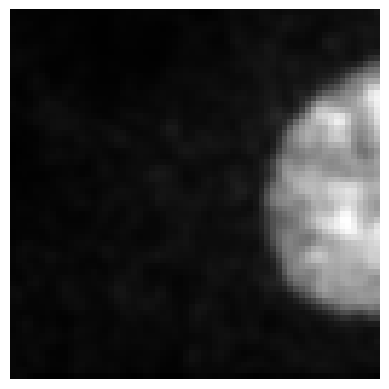

In [ ]:
# Extract target array pointers for input and ground truth (gt) from sample 1
input_file_path = f"{output_folder}/patches_dataset.h5/{manifest_df['image'][1]}"
gt_file_path = f"{output_folder}/patches_dataset.h5/{manifest_df['gt'][1]}"

# Load and visualize the preprocessed input patch array
im_in, meta_in, affine_in = hdf5_loader()(input_file_path)
print("--- INPUT PATCH METADATA ---")
print(f"Metadata Attributes:\n{meta_in}\n")
print(f"Affine Matrix:\n{affine_in}\n")
show_image(im_in)

# Load and visualize the preprocessed target (ground-truth) patch array
im_gt, meta_gt, affine_gt = hdf5_loader()(gt_file_path)
print("--- TARGET PATCH METADATA ---")
print(f"Metadata Attributes:\n{meta_gt}\n")
print(f"Affine Matrix:\n{affine_gt}\n")
show_image(im_gt)

##### Step 3: Randomized Sub-sampling with Downstream Patch Transforms

Alternatively, we can compile a dataset using a stochastic approach with a [`RandomPatchSplitter`](https://deepCLEM.github.io/bioMONAI/data.tfms.html#randompatchsplitter). In this scenario, augmentations (`patch_transforms`) are applied directly to individual extracted sub-patch slices instead of the global image.


Processing split: train


100%|██████████| 5/5 [00:00<00:00, 71.35it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 72.75it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset_random.h5
Patch information saved to CSV: ./_test_tfms/patches_dataset_random.csv
--- RANDOMIZED PATCH METADATA ---
{'affine': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), 'depth': '1', 'dimensions_present': 'YXC', 'dtype': 'uint8', 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510002.png', 'format': 'PNG', 'image_size_c': '3', 'image_size_x': '512', 'image_size_y': '512', 'kind': 'image', 'layout': 'CZYX', 'mode': 'RGB', 'original_channel_dim': '0', 'patch_size': '(64, 64)', 'patch_transforms': "{'GaussianSmoothd': {'__class__': 'GaussianSmoothd', 'keys': ('gt',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 1, 'approx': 'erf'}}}", 'size_after_tfms': 'torch.Size([3, 1, 512, 512])', 'size_loaded': 'torch.Size([3, 1, 512, 512])', 'size_output': '(3, 1, 512, 512)', 'source_shape': '(3, 1, 512, 512)', 'space':

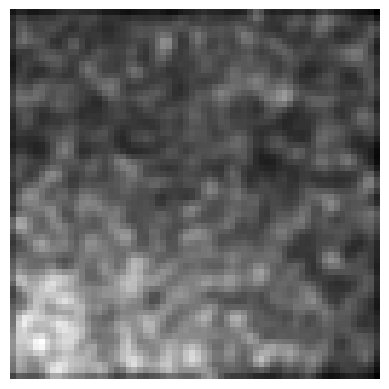

In [ ]:
# Execute end-to-end stochastic patch sub-sampling
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset_random',
    colmap=colmap, 
    patch_transforms=transforms_list, 
    image_splitter=RandomPatchSplitter(patch_size, num_patches=3), 
)

# Load and verify a sample from the randomized dataset matrix
random_df = pd.read_csv(f'{output_folder}/patches_dataset_random.csv')
random_h5_path = f"{output_folder}/patches_dataset_random.h5/{random_df['gt'][1]}"

rand_gt, rand_meta, _ = hdf5_loader()(random_h5_path)
print("--- RANDOMIZED PATCH METADATA ---")
print(rand_meta)
show_image(rand_gt)